# MASt3R — Plant 3D Reconstruction (front-only, 40 images)

Pipeline:
- Input: `plant_front40_cropped.zip` (40 cropped, front-arc images — no masks, no GT poses)
- Poses: computed by MASt3R itself (no Gazebo / no yaml)
- Output: point cloud + poses saved straight to **Google Drive** (nothing downloaded locally)


## 0. Check GPU

In [1]:
!nvidia-smi
import torch
print("CUDA available:", torch.cuda.is_available())


Wed Jul 22 00:40:42 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.82.07              Driver Version: 580.82.07      CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla T4                       Off |   00000000:00:04.0 Off |                    0 |
| N/A   37C    P8              9W /   70W |       0MiB /  15360MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

## 1. Mount Google Drive
Everything this notebook produces gets saved under `OUTPUT_DIR` on your Drive — set the folder name you want below.

In [2]:
from google.colab import drive
drive.mount('/content/drive')

import os
OUTPUT_DIR = '/content/drive/MyDrive/mast3r_plant_results_final2'
os.makedirs(OUTPUT_DIR, exist_ok=True)
print("Results will be saved to:", OUTPUT_DIR)


Mounted at /content/drive
Results will be saved to: /content/drive/MyDrive/mast3r_plant_results_final2


## 2. Install MASt3R

In [3]:
%cd /content
!git clone --recursive https://github.com/naver/mast3r
%cd /content/mast3r
!pip install -q -r requirements.txt
!pip install -q -r dust3r/requirements.txt
!pip install -q -r dust3r/requirements_optional.txt || true
!pip install -q open3d

!mkdir -p checkpoints
!wget -q --show-progress -O checkpoints/MASt3R_ViTLarge_BaseDecoder_512_catmlpdpt_metric.pth \
    https://download.europe.naverlabs.com/ComputerVision/MASt3R/MASt3R_ViTLarge_BaseDecoder_512_catmlpdpt_metric.pth


/content
Cloning into 'mast3r'...
remote: Enumerating objects: 269, done.
remote: Counting objects: 100% (170/170), done.
remote: Compressing objects: 100% (61/61), done.
remote: Total 269 (delta 115), reused 109 (delta 109), pack-reused 99 (from 1)
Receiving objects: 100% (269/269), 3.59 MiB | 9.29 MiB/s, done.
Resolving deltas: 100% (151/151), done.
Submodule 'dust3r' (https://github.com/naver/dust3r) registered for path 'dust3r'
Cloning into '/content/mast3r/dust3r'...
remote: Enumerating objects: 611, done.        
remote: Total 611 (delta 0), reused 0 (delta 0), pack-reused 611 (from 1)        
Receiving objects: 100% (611/611), 756.60 KiB | 2.05 MiB/s, done.
Resolving deltas: 100% (355/355), done.
Submodule path 'dust3r': checked out '3cc8c88c413bb9e34c41db0e0eef99c2ee010b12'
Submodule 'croco' (https://github.com/naver/croco) registered for path 'dust3r/croco'
Cloning into '/content/mast3r/dust3r/croco'...
remote: Enumerating objects: 198, done.        
remote: Counting objects: 

## 3. Upload and unzip your dataset
Upload `plant_front40_cropped.zip` when prompted (the 40 front-arc, pre-cropped images — no masks, no yaml).

In [4]:
from google.colab import files
import zipfile, os, glob

uploaded = files.upload()  # select plant_front40_cropped.zip
zip_name = list(uploaded.keys())[0]

with zipfile.ZipFile(zip_name, 'r') as z:
    z.extractall('/content/data')

Saving plant3_back.zip to plant3_back.zip


In [5]:
import os
import glob

# find the folder that actually contains the images, regardless of exact zip layout
candidates = [r for r, d, f in os.walk('/content/data') if any(fn.lower().endswith('.png') for fn in f)]
assert candidates, "No .png images found after extracting the zip — check the zip contents"
DATASET_ROOT = candidates[0]

image_paths = sorted(
    glob.glob(os.path.join(DATASET_ROOT, '*.png')),
    key=lambda p: int(''.join(filter(str.isdigit, os.path.basename(p))) or 0)
)
print(f"Found {len(image_paths)} images in {DATASET_ROOT}")
assert len(image_paths) == 139, f"Expected 60 images, found {len(image_paths)} — check the upload"

Found 139 images in /content/data/plant3_back



# Filter image_paths to process every other image divide 2

In [ ]:
# Select every other image to reduce processing time
image_paths = image_paths[::2]
print(f"Reduced image_paths to {len(image_paths)} images by taking every other image.")

Reduced image_paths to 198 images by taking every other image.


# 4. Load MASt3R model + images

In [16]:
import sys
sys.path.insert(0, '/content/mast3r')
sys.path.insert(0, '/content/mast3r/dust3r')

from mast3r.model import AsymmetricMASt3R
from mast3r.cloud_opt.sparse_ga import sparse_global_alignment
from dust3r.utils.image import load_images

device = "cuda"

model = AsymmetricMASt3R.from_pretrained(
    "naver/MASt3R_ViTLarge_BaseDecoder_512_catmlpdpt_metric"
).to(device)

imgs = load_images(image_paths, size=512)
print(f"Loaded {len(imgs)} images for inference")


>> Loading a list of 139 images
 - adding /content/data/plant3_back/frame_0.png with resolution 640x480 --> 512x384
 - adding /content/data/plant3_back/frame_1.png with resolution 640x480 --> 512x384
 - adding /content/data/plant3_back/frame_2.png with resolution 640x480 --> 512x384
 - adding /content/data/plant3_back/frame_3.png with resolution 640x480 --> 512x384
 - adding /content/data/plant3_back/frame_4.png with resolution 640x480 --> 512x384
 - adding /content/data/plant3_back/frame_5.png with resolution 640x480 --> 512x384
 - adding /content/data/plant3_back/frame_6.png with resolution 640x480 --> 512x384
 - adding /content/data/plant3_back/frame_7.png with resolution 640x480 --> 512x384
 - adding /content/data/plant3_back/frame_8.png with resolution 640x480 --> 512x384
 - adding /content/data/plant3_back/frame_9.png with resolution 640x480 --> 512x384
 - adding /content/data/plant3_back/frame_10.png with resolution 640x480 --> 512x384
 - adding /content/data/plant3_back/frame_1

#check install

In [13]:
import os

checkpoint_file_path = ckpt  # Using the 'ckpt' variable from the previous cell

if os.path.exists(checkpoint_file_path):
    file_size_bytes = os.path.getsize(checkpoint_file_path)
    file_size_mb = file_size_bytes / (1024 * 1024)
    print(f"Checkpoint file size: {file_size_mb:.2f} MB")
else:
    print(f"Checkpoint file not found at: {checkpoint_file_path}")

# Expected size for MASt3R_ViTLarge_BaseDecoder_512_catmlpdpt_metric.pth is approximately 1.76 GB
# (1760 MB). If the size is significantly smaller, the download was incomplete.

Checkpoint file size: 0.00 MB


In [10]:
!curl -I https://download.europe.naverlabs.com/ComputerVision/MASt3R/MASt3R_ViTLarge_BaseDecoder_512_catmlpdpt_metric.pth

curl: (28) Failed to connect to download.europe.naverlabs.com port 443 after 136675 ms: Connection timed out


In [8]:
!rm -f checkpoints/MASt3R_ViTLarge_BaseDecoder_512_catmlpdpt_metric.pth

!wget \
-O checkpoints/MASt3R_ViTLarge_BaseDecoder_512_catmlpdpt_metric.pth \
https://download.europe.naverlabs.com/ComputerVision/MASt3R/MASt3R_ViTLarge_BaseDecoder_512_catmlpdpt_metric.pth

--2026-07-22 00:48:19--  https://download.europe.naverlabs.com/ComputerVision/MASt3R/MASt3R_ViTLarge_BaseDecoder_512_catmlpdpt_metric.pth
Resolving download.europe.naverlabs.com (download.europe.naverlabs.com)... 110.234.56.25
Connecting to download.europe.naverlabs.com (download.europe.naverlabs.com)|110.234.56.25|:443... connected.
Unable to establish SSL connection.


In [11]:
from mast3r.model import AsymmetricMASt3R

model = AsymmetricMASt3R.from_pretrained(
    "naver/MASt3R_ViTLarge_BaseDecoder_512_catmlpdpt_metric"
).to("cuda")

config.json:   0%|          | 0.00/546 [00:00<?, ?B/s]

model.safetensors: reconstructing file:   0%|          |  0.00B / 2.75GB            

model.safetensors: downloading bytes:           |  0.00B            

In [15]:
from huggingface_hub import scan_cache_dir

cache = scan_cache_dir()

for repo in cache.repos:
    if "MASt3R" in repo.repo_id:
        print("Repo:", repo.repo_id)
        print("Path:", repo.repo_path)

Repo: naver/MASt3R_ViTLarge_BaseDecoder_512_catmlpdpt_metric
Path: /root/.cache/huggingface/hub/models--naver--MASt3R_ViTLarge_BaseDecoder_512_catmlpdpt_metric


## 5. Run sparse global alignment (MASt3R computes poses itself)
40 images with `scene_graph='complete'` = 780 pairs. Fine on a T4 — expect this to take on the order of
10-30 minutes, not hours. If it's clearly stuck past that, stop and check the log rather than leaving it overnight.

In [17]:
from mast3r.image_pairs import make_pairs
import tempfile
pairs = make_pairs(imgs, scene_graph='logwin-8-cyclic', prefilter=None, symmetrize=True)
print(f"{len(pairs)} pairs from {len(imgs)} images")

cache_dir = tempfile.mkdtemp(prefix='mast3r_cache_')

scene = sparse_global_alignment(
    image_paths,
    pairs,
    cache_dir,
    model,
    lr1=0.07, niter1=500,
    lr2=0.014, niter2=200,
    device=device,
    opt_depth=True,
    matching_conf_thr=5.0,
)
print("Alignment done.")


2224 pairs from 139 images


  0%|          | 0/2224 [00:00<?, ?it/s]/content/mast3r/mast3r/cloud_opt/sparse_ga.py:620: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast(enabled=False):
100%|██████████| 139/139 [01:18<00:00,  1.78it/s]


init focals = [324.57062 323.6804  325.4425  319.9155  322.30148 321.6835  328.77072
 325.5159  322.57855 322.79352 320.16516 318.061   322.39188 320.90402
 322.92776 320.27695 323.17563 321.98    328.5872  319.4524  322.7744
 329.33072 340.74188 333.68848 345.5417  340.60007 339.7613  335.51355
 343.42615 335.65884 337.8203  337.9545  332.24176 337.7417  343.05692
 337.75748 339.11172 338.97806 345.05417 337.11996 342.43326 334.61136
 341.6569  336.95895 339.71915 342.29254 334.49634 340.6623  341.18362
 336.36386 334.36383 340.99414 339.08377 336.09335 331.56473 337.43985
 333.41016 328.69922 325.9555  326.33618 331.18756 333.2393  327.81458
 332.9105  332.66708 327.8754  327.54114 328.7262  327.8369  325.15802
 325.61838 329.514   331.61957 328.98083 341.49075 339.29565 341.567
 341.31674 333.6059  341.14783 339.4868  339.4769  340.20352 342.48157
 337.49182 330.7477  332.02826 333.62195 335.44223 334.88876 336.01324
 335.7011  334.68887 337.48444 332.33777 327.8144  330.25143 336.5

  0%|          | 0/500 [00:00<?, ?it/s]/content/mast3r/mast3r/cloud_opt/sparse_ga.py:457: UserWarning: Converting a tensor with requires_grad=True to a scalar may lead to unexpected behavior.
Consider using tensor.detach() first. (Triggered internally at /pytorch/torch/csrc/autograd/generated/python_variable_methods.cpp:836.)
  loss = float(loss)
100%|██████████| 500/500 [09:20<00:00,  1.12s/it, lr=0.0000, loss=0.029]


>> final loss = 0.02915474772453308


100%|██████████| 200/200 [04:36<00:00,  1.38s/it, lr=0.0000, loss=0.356]


>> final loss = 0.35615774989128113
Final focals = [353.8544  353.9062  353.78824 353.91904 353.61252 354.10773 355.11435
 356.41125 358.27316 359.03607 359.6646  360.64075 361.36353 362.01907
 362.99365 363.72604 365.0236  365.11166 365.14423 364.60245 365.21738
 366.42606 366.82498 367.29773 367.14136 365.16147 362.1631  357.2014
 353.82892 355.5776  353.04507 351.0625  348.87323 347.1986  345.925
 344.66296 343.8194  343.14526 342.60165 342.2979  342.0341  341.67172
 341.2137  340.56516 340.7755  340.43573 340.0099  339.40668 338.60538
 337.58374 337.26614 336.22705 335.42142 334.4024  332.9472  331.37442
 330.19662 328.34457 327.3884  326.2144  324.45505 323.74722 323.1534
 322.42172 322.7838  323.62067 323.61264 324.2643  325.03665 325.3832
 325.13647 324.85086 324.29727 324.11575 324.4971  324.95886 325.6145
 326.97028 328.42194 329.64902 330.76993 332.3411  334.9875  337.54462
 339.8885  344.6932  347.20322 350.6033  352.04837 353.03348 354.41385
 355.34827 355.775   355.1235  3

## 6. Save the poses MASt3R computed
These are the camera poses (camera-to-world) and intrinsics estimated directly from the images —
no Gazebo, no yaml, no manual alignment.

In [ ]:
print([m for m in dir(scene) if m.startswith('get_')])

['get_dense_pts3d', 'get_depthmaps', 'get_focals', 'get_im_poses', 'get_masks', 'get_principal_points', 'get_pts3d_colors', 'get_sparse_pts3d']


In [18]:
import numpy as np

poses_c2w = scene.get_im_poses().detach().cpu().numpy()   # (N,4,4)

focals = scene.get_focals().detach().cpu().numpy().reshape(-1)   # (N,)
pps = scene.get_principal_points().detach().cpu().numpy()        # (N,2)

N = len(focals)
intrinsics = np.zeros((N, 3, 3), dtype=np.float32)
for i in range(N):
    intrinsics[i, 0, 0] = focals[i]
    intrinsics[i, 1, 1] = focals[i]
    intrinsics[i, 0, 2] = pps[i, 0]
    intrinsics[i, 1, 2] = pps[i, 1]
    intrinsics[i, 2, 2] = 1.0

np.save(os.path.join(OUTPUT_DIR, 'poses_c2w.npy'), poses_c2w)
np.save(os.path.join(OUTPUT_DIR, 'intrinsics.npy'), intrinsics)
print("Saved poses_c2w.npy and intrinsics.npy to", OUTPUT_DIR)

Saved poses_c2w.npy and intrinsics.npy to /content/drive/MyDrive/mast3r_plant_results_final2


## 7. Export the point cloud
`CONF_THR` controls how strict the confidence filtering is — raise it if you see streaky/noisy points,
lower it if the cloud looks too sparse/holey.

In [19]:
pts3d, _, confs = scene.get_dense_pts3d(clean_depth=True)
imgs_rgb = scene.imgs

CONF_THR = 1.3

all_pts, all_colors = [], []
for p, c, im in zip(pts3d, confs, imgs_rgb):
    p = p.reshape(-1, 3).detach().cpu().numpy()
    conf = c.reshape(-1).detach().cpu().numpy()
    mask = conf > CONF_THR
    all_pts.append(p[mask])
    all_colors.append(im.reshape(-1, 3)[mask])

all_pts = np.concatenate(all_pts, axis=0)
all_colors = np.concatenate(all_colors, axis=0)
print(f"Total points before cleanup: {len(all_pts):,}")


Total points before cleanup: 1,751,921


## 8. Clean up + save the .ply straight to Drive

In [20]:
import open3d as o3d

pcd = o3d.geometry.PointCloud()
pcd.points = o3d.utility.Vector3dVector(all_pts)
pcd.colors = o3d.utility.Vector3dVector(np.clip(all_colors, 0, 1))

# statistical outlier removal — strips stray floating points from bad matches
pcd, _ = pcd.remove_statistical_outlier(nb_neighbors=20, std_ratio=2.0)
# radius outlier removal — catches small isolated blobs the statistical pass misses
pcd, _ = pcd.remove_radius_outlier(nb_points=8, radius=0.05)

ply_path = os.path.join(OUTPUT_DIR, 'plant_pointcloud.ply')
o3d.io.write_point_cloud(ply_path, pcd)
print(f"Points after cleanup: {len(pcd.points):,}")
print("Saved:", ply_path)


Points after cleanup: 1,715,105
Saved: /content/drive/MyDrive/mast3r_plant_results_final2/plant_pointcloud.ply


## 9. Quick qualitative check (saved to Drive, not just shown here)

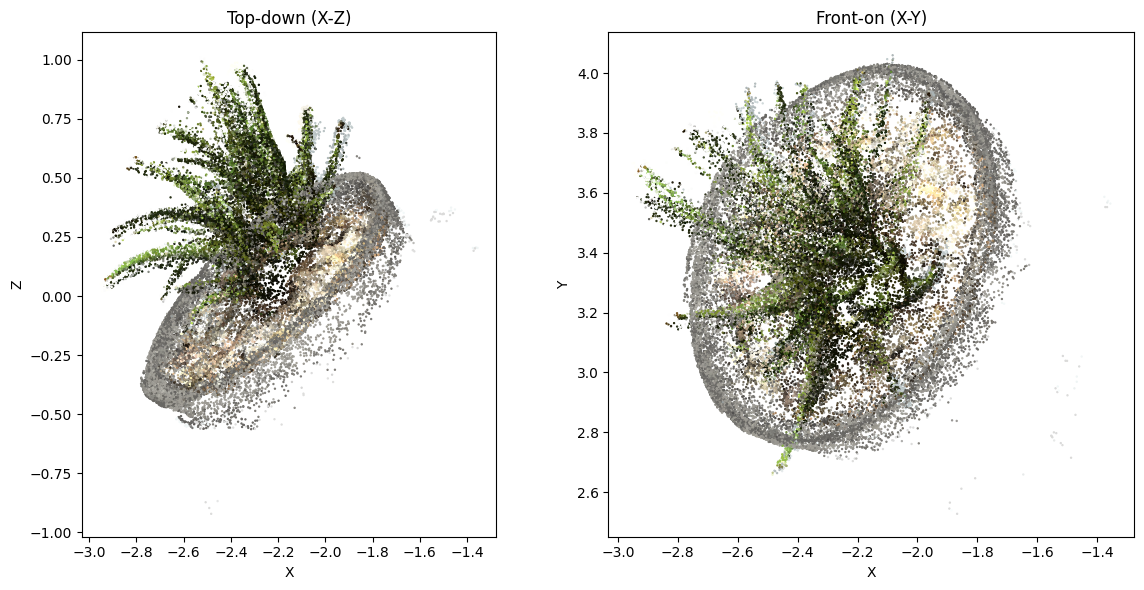

Saved check image to Drive.


In [21]:
import matplotlib.pyplot as plt

pts_arr = np.asarray(pcd.points)
colors_arr = np.asarray(pcd.colors)
sample = np.random.choice(len(pts_arr), size=min(50000, len(pts_arr)), replace=False)

fig, axes = plt.subplots(1, 2, figsize=(12, 6))
axes[0].scatter(pts_arr[sample, 0], pts_arr[sample, 2], c=colors_arr[sample], s=0.5)
axes[0].set_title('Top-down (X-Z)'); axes[0].set_xlabel('X'); axes[0].set_ylabel('Z'); axes[0].set_aspect('equal')

axes[1].scatter(pts_arr[sample, 0], pts_arr[sample, 1], c=colors_arr[sample], s=0.5)
axes[1].set_title('Front-on (X-Y)'); axes[1].set_xlabel('X'); axes[1].set_ylabel('Y'); axes[1].set_aspect('equal')

plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, 'pointcloud_check.png'), dpi=120)
plt.show()
print("Saved check image to Drive.")


## 10. Diagnostics — where is it failing?
Per-image confidence and point-count stats. Low bars = weak images (bad angle, motion blur, too little overlap
with neighbors) — these are your prime suspects if the point cloud has holes or noise on a specific part of the plant.

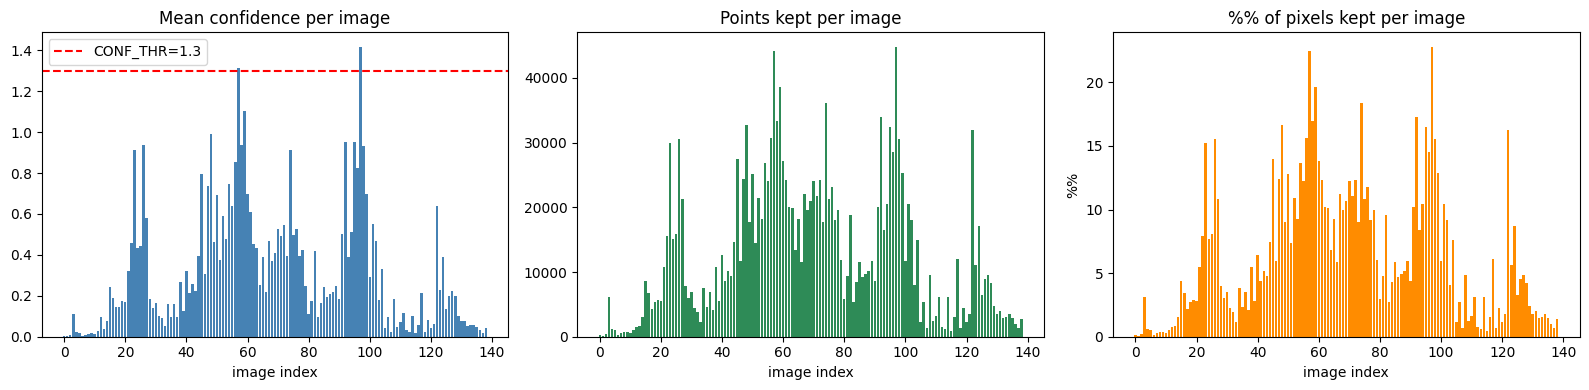

5 weakest images (lowest mean confidence) — check these first if you see holes/noise:
  image 1: frame_1.png  mean_conf=0.00  kept=155/196,608
  image 0: frame_0.png  mean_conf=0.00  kept=272/196,608
  image 6: frame_6.png  mean_conf=0.00  kept=263/196,608
  image 2: frame_2.png  mean_conf=0.01  kept=437/196,608
  image 7: frame_7.png  mean_conf=0.01  kept=525/196,608


In [22]:
import numpy as np
import matplotlib.pyplot as plt

n_imgs = len(pts3d)
mean_conf_per_img = []
pts_kept_per_img = []
pts_total_per_img = []

for p, c in zip(pts3d, confs):
    conf = c.reshape(-1).detach().cpu().numpy()
    mean_conf_per_img.append(conf.mean())
    pts_kept_per_img.append(int((conf > CONF_THR).sum()))
    pts_total_per_img.append(conf.size)

mean_conf_per_img = np.array(mean_conf_per_img)
pts_kept_per_img = np.array(pts_kept_per_img)
keep_ratio = pts_kept_per_img / np.array(pts_total_per_img)

fig, axes = plt.subplots(1, 3, figsize=(16, 4))

axes[0].bar(range(n_imgs), mean_conf_per_img, color='steelblue')
axes[0].axhline(CONF_THR, color='red', linestyle='--', label=f'CONF_THR={CONF_THR}')
axes[0].set_title('Mean confidence per image'); axes[0].set_xlabel('image index'); axes[0].legend()

axes[1].bar(range(n_imgs), pts_kept_per_img, color='seagreen')
axes[1].set_title('Points kept per image'); axes[1].set_xlabel('image index')

axes[2].bar(range(n_imgs), keep_ratio * 100, color='darkorange')
axes[2].set_title('%% of pixels kept per image'); axes[2].set_xlabel('image index'); axes[2].set_ylabel('%%')

plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, 'diagnostics_per_image.png'), dpi=120)
plt.show()

# flag the weakest images
weak_idx = np.argsort(mean_conf_per_img)[:5]
print("5 weakest images (lowest mean confidence) — check these first if you see holes/noise:")
for i in weak_idx:
    print(f"  image {i}: {os.path.basename(image_paths[i])}  mean_conf={mean_conf_per_img[i]:.2f}  kept={pts_kept_per_img[i]:,}/{pts_total_per_img[i]:,}")


### Confidence heatmaps for the weakest images
Visualizes *where in the image* MASt3R was unsure — dark/low areas are where matching failed
(often thin leaf edges, specular highlights, or background clutter).

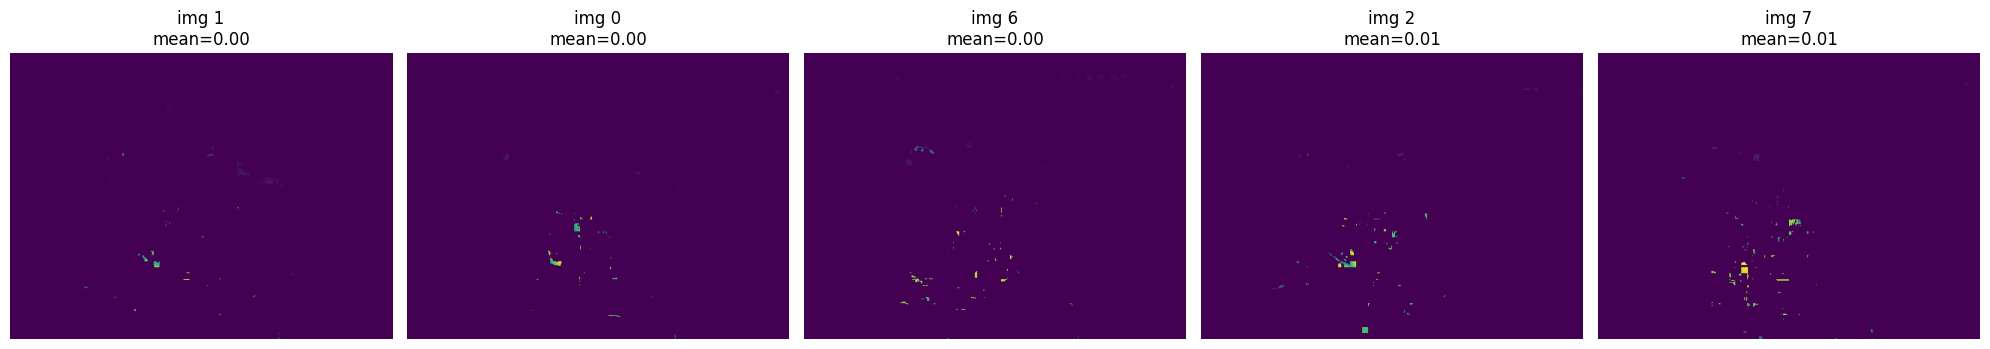

Saved diagnostics to Drive: diagnostics_per_image.png, diagnostics_confidence_maps.png


In [23]:
fig, axes = plt.subplots(1, len(weak_idx), figsize=(4*len(weak_idx), 4))
if len(weak_idx) == 1:
    axes = [axes]

for ax, i in zip(axes, weak_idx):
    conf_map = confs[i].detach().cpu().numpy()
    im = ax.imshow(conf_map, cmap='viridis')
    ax.set_title(f'img {i}\nmean={mean_conf_per_img[i]:.2f}')
    ax.axis('off')

plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, 'diagnostics_confidence_maps.png'), dpi=120)
plt.show()
print("Saved diagnostics to Drive: diagnostics_per_image.png, diagnostics_confidence_maps.png")


## 11. Done
Everything is in `OUTPUT_DIR` on your Drive:
- `plant_pointcloud.ply` — open directly in COLMAP GUI, CloudCompare, or MeshLab
- `poses_c2w.npy`, `intrinsics.npy` — MASt3R-estimated camera poses/intrinsics
- `pointcloud_check.png` — quick visual sanity check
- `diagnostics_per_image.png`, `diagnostics_confidence_maps.png` — per-image confidence/failure diagnostics

**Reminder:** this is a front-only reconstruction (single arc, ~40 frames spanning less than half the plant's
full rotation). It will not have geometry for the back of the plant — that's expected given the input, not a bug.

In [ ]:
print("Contents of", OUTPUT_DIR)
for f in sorted(os.listdir(OUTPUT_DIR)):
    print(" -", f)


Contents of /content/drive/MyDrive/mast3r_plant_results
 - diagnostics_confidence_maps.png
 - diagnostics_per_image.png
 - intrinsics.npy
 - plant_pointcloud.ply
 - pointcloud_check.png
 - poses_c2w.npy
